# SAMI — Notebook 3 · Emergent themes & emotion (NLP)

**NLP only.** This notebook discovers the semantic structure of the messages
automatically and contrasts it with the official MMC taxonomy: KMeans over
sentence embeddings (primary) and lemmatized TF-IDF (comparison), the
cluster-vs-taxonomy agreement, the **emergent themes** the 7 categories do not
capture, the qualitative voices of users, per-message **sentiment** as an
unsolicited distress signal, and a closing **geographic synthesis** of need +
tone by city.

*Descriptive cross-cuts by category live in Notebook 2.*

---

### Objectives
- Discover the semantic sub-themes automatically and contrast them with the 7
  official MMC categories, reading the **user-level** clusters as migrant
  situations / profiles (archetypes), not just text classes.
- Detect **emergent needs** the taxonomy — and possibly the bot itself — does
  not cover, as concrete inputs to the architecture recommendation (e.g. the
  recurring *transport / logistics* questions the 7 categories have no slot for).
- Surface qualitative voices: a word cloud + a thematic read of comments.
- Measure the emotional tone of messages as a signal of unsolicited distress.
- Synthesize geographically where the greatest need concentrates.

### Guiding questions
1. Do the automatic clusters confirm the official MMC categories?
2. Which needs, not contemplated by the taxonomy, appear anyway?
3. How negative or positive is the tone of messages, and does it vary by category?
4. Where does the most urgent need concentrate geographically, together with
   emotional distress?

### Hypotheses
- **H1.** Most clusters coincide reasonably with the 7 MMC categories.
- **H2.** There are 2–4 real emergent themes (not noise) the taxonomy misses.
- **H3.** The predominant tone is neutral-negative, concentrated in
  regularization / legal categories.
- **H4.** Emotional distress concentrates in specific cities, coinciding with
  high demand for legal documentation.


## 0. Setup, data & original classification

In [1]:
# Imports. Collapsed on purpose -- no analysis here.
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from collections import Counter
from wordcloud import WordCloud

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
GPU = 0 if DEVICE == "cuda" else -1

In [2]:
# ---- Brand palette (SAMI) ----------------------------------------------------
# Official SAMI colours, shared verbatim with Notebooks 1 & 2 (agua #6281DA is
# the brand blue confirmed in the previous report). Blue is the workhorse for
# magnitude; the accent hues (arbol/ameba) and the neutral (madera) carry
# categorical identity. Where a chart needs MORE than the 4 core hues (the 7 MMC
# categories, the 7 KMeans clusters) we extend with SHADES from the same brand
# families -- never a new off-brand hue. Re-theme by editing THIS cell only.
from matplotlib.colors import LinearSegmentedColormap, ListedColormap, to_hex

COLORES = {
    "agua":   "#6281DA",   # brand blue (primary)
    "madera": "#8E8E78",   # olive-grey (neutral)
    "hongo":  "#E0DDDC",   # warm light grey (grid / tracks)
    "negro":  "#000000",
    "cielo":  "#EFEFEF",   # light grey (soft surface)
    "ameba":  "#D5A9EA",   # lilac (accent)
    "arbol":  "#6E8149",   # green (accent)
}
AGUA, MADERA, HONGO = COLORES["agua"], COLORES["madera"], COLORES["hongo"]
NEGRO, ARBOL, AMEBA, CIELO = COLORES["negro"], COLORES["arbol"], COLORES["ameba"], COLORES["cielo"]

PRIMARY  = AGUA
DARKBLUE = "#26386e"       # darker blue for line/border EMPHASIS only -- the gradient itself tops at brand blue
BLUE_CMAP = LinearSegmentedColormap.from_list(
    "sami_agua", ["#f2f5fc", "#d9e1f6", "#bdcaf0", "#9db1e8", "#819ae1", "#6281DA"])

def seq_colors(n, lo=0.30, hi=1.0):
    "n blues, light->dark, for an ordered magnitude (small->large)."
    if n <= 1:
        return [PRIMARY]
    return [BLUE_CMAP(lo + (hi - lo) * i / (n - 1)) for i in range(n)]

def seq_by_value(values, lo=0.22, hi=1.0):
    "One blue per value, shade scaled to the value itself (min->max)."
    v = np.asarray(values, dtype=float)
    if v.size == 0 or v.max() == v.min():
        return [PRIMARY] * len(v)
    t = (v - v.min()) / (v.max() - v.min())
    return [BLUE_CMAP(lo + (hi - lo) * ti) for ti in t]

BLUE_SEQ = BLUES = seq_colors(6)

# Core categorical identity set: 4 brand hues, madera = neutral residual.
CAT = [AGUA, ARBOL, AMEBA, MADERA]
NEUTRAL = MADERA
EARTH = CAT

# Extended 7-swatch set for charts that genuinely need >4 categories (the 7 MMC
# categories, the 7 KMeans clusters). Beyond the 4 core hues we add brand-family
# shades ONLY: navy (blue-ramp end), light brand blue, deep arbol green.
CAT7 = [AGUA, ARBOL, AMEBA, MADERA, DARKBLUE, "#9cabe7", "#47552f"]
CAT_CMAP = ListedColormap(CAT7, name="sami_cat")

def cat_colors(n):
    "n distinct categorical colours from the brand family (no off-brand cycling)."
    if n > len(CAT7):
        return CAT7[:-1] + [NEUTRAL] * (n - len(CAT7) + 1)
    return CAT7[:n]

def bar_colors(n):
    return seq_colors(n)

# Text / structure tokens.
INK   = NEGRO
INK2  = "#4d4d4d"
MUTED = MADERA
GRID  = HONGO
SURFACE = "white"

# Diverging pair, consistent with NB2: blue = positive/over, olive = negative/under.
DIV_POS, DIV_NEG = AGUA, MADERA

def pct_count_autopct(values, min_pct=3.0):
    total = float(sum(values))
    def _fmt(pct):
        return "" if pct < min_pct else f"{pct:.1f}%\n({int(round(pct/100*total))})"
    return _fmt

In [3]:
# Data loaders -- inlined so the notebook is fully self-contained (no external module).
import re, unicodedata

DATA_DIR = "../data_&_docs"
RESPONSES_PATH = DATA_DIR + "/MMC_bot_responses_1783087815.xlsx"
MEAL_PATH = DATA_DIR + "/MMC_MEAL_1783087939.xlsx"
DATA_HEADER_ROW = 2  # header is the 3rd row of the export

def _phone(name):
    return re.sub(r"\D", "", str(name))

_CITY_CANON = {
    "medellin": "Medellín", "medellin antioquia": "Medellín", "belen": "Medellín",
    "bogota": "Bogotá", "bogota dc": "Bogotá",
    "cucuta": "Cúcuta",
    "barranquilla": "Barranquilla",
    "santa marta": "Santa Marta",
    "cali": "Cali",
    "cartagena": "Cartagena",
    "bucaramanga": "Bucaramanga",
    "ipiales": "Ipiales",
    "riohacha": "Riohacha", "maicao": "Maicao",
    "soacha": "Soacha", "soacha cundinamarca": "Soacha",
    "necocli": "Necoclí",
}
_NON_CITY = {"colombia", "cundinamarca", "antioquia", "otra", "nan"}

def _fold(s):
    s = unicodedata.normalize("NFKD", str(s))
    s = "".join(c for c in s if not unicodedata.combining(c))
    return s.strip().lower()

def city_canon(name):
    if name is None:
        return "Otra"
    key = _fold(name)
    if key in _NON_CITY or key == "":
        return "Otra"
    if key in _CITY_CANON:
        return _CITY_CANON[key]
    for k, v in _CITY_CANON.items():
        if key.startswith(k):
            return v
    return "Otra"

def clean_city(raw_city, city_other):
    raw = ("" if raw_city is None else str(raw_city)).strip()
    other = "" if city_other is None or pd.isna(city_other) else str(city_other).strip()
    if raw == "Otra" and other:
        return other.title()
    return raw

def _read_whatsapp(path):
    d = pd.read_excel(path, header=DATA_HEADER_ROW)
    d = d[d["Name"].astype(str).str.startswith("whatsapp")].copy()
    d.reset_index(drop=True, inplace=True)
    return d

def load_responses(path=RESPONSES_PATH):
    d = _read_whatsapp(path)
    d["phone"] = d["Name"].map(_phone)
    d["city_clean"] = [clean_city(c, o) for c, o in zip(d["City"], d["City_other"])]
    d["city_canon"] = d["city_clean"].map(city_canon)
    d["age_num"] = pd.to_numeric(d["Age"], errors="coerce")
    d["ts"] = pd.to_datetime(d["Timestamp"], errors="coerce", utc=True).dt.tz_localize(None)
    d["n_questions"] = pd.to_numeric(d["Questions per user"], errors="coerce")
    return d

def load_meal(path=MEAL_PATH):
    d = _read_whatsapp(path)
    d["phone"] = d["Name"].map(_phone)
    cols = list(d.columns)
    d = d.rename(columns={cols[2]: "utility", cols[3]: "would_recommend",
                          cols[4]: "recommendation", cols[5]: "heard_channel",
                          cols[6]: "heard_medium"})
    d["ts"] = pd.to_datetime(d["Timestamp"], errors="coerce", utc=True).dt.tz_localize(None)
    return d

_NOISE = {"undefined", "?", ""}
def _is_noise(t):
    t = t.strip()
    return len(t) < 3 or t.isdigit() or t.lower() in _NOISE

def load_messages(d=None):
    """Explode the per-user `Messages` blob into one row per user turn."""
    if d is None:
        d = load_responses()
    carry = ["phone", "city_clean", "city_canon", "ts", "Gender",
             "Age Ranges", "Nationality", "age_num"]
    carry = [c for c in carry if c in d.columns]
    rows = []
    for _, r in d.iterrows():
        blob = r.get("Messages")
        if not isinstance(blob, str):
            continue
        parts = [p.strip() for p in blob.split("\n")]
        parts = [p for p in parts if not _is_noise(p)]
        for i, p in enumerate(parts):
            row = {c: r[c] for c in carry}
            row["msg_idx"] = i
            row["n_msgs_user"] = len(parts)
            row["message"] = p
            rows.append(row)
    return pd.DataFrame(rows).reset_index(drop=True)

In [4]:
# The 7 official MMC categories, each with a short Spanish hypothesis. The
# category KEYS (English) are what gets displayed on every chart; the VALUES
# stay in Spanish because they are aligned with the bot's original Chat_summary labels. Short labels were chosen by measuring agreement against the bot's
# own Chat_summary labels (see the validation cell in Section 3): they gave the
# best balanced accuracy — long keyword-stuffed descriptions collapsed onto one or two categories.
MMC_LABELS = {
    "legal documentation":     "documentación legal y trámites migratorios",
    "humanitarian assistance": "ayuda humanitaria",
    "employment":              "empleo",
    "health & services":       "salud y servicios",
    "protection":              "protección y seguridad",
    "journey information":     "información de viaje",
    "organization search":     "búsqueda de una organización",
}
MMC_CATS = list(MMC_LABELS)
COURTESY = "courtesy / non-substantive"
NOISE    = "unclustered"
FRAG     = "short fragment"                 # location/greeting fragments, not a theme
NON_TOPIC_CATS = [COURTESY, NOISE, FRAG]    # excluded from topic cross-cuts

# one distinct colour per category (brand colours first, then muted extras)
CAT_COLORS = {
    "legal documentation":     AGUA,
    "humanitarian assistance": ARBOL,
    "employment":              AMEBA,
    "health & services":       MADERA,
    "protection":              DARKBLUE,
    "journey information":     "#9cabe7",
    "organization search":     "#47552f",
    "emergent":                "#b98fd0",
    COURTESY:                  HONGO,
    NOISE:                     "#cfcfcf",
    FRAG:                      "#b0b0b0",
}
def cat_palette(cats):
    return [CAT_COLORS.get(c, NEGRO) for c in cats]

In [5]:
df   = load_responses()          # one row per user (has Chat_summary)
msgs = load_messages(df)         # one row per user message (the spine)
print(f"users: {len(df)}  |  messages: {len(msgs)}  |  device: {DEVICE}"
      + (f" ({torch.cuda.get_device_name(0)})" if DEVICE == "cuda" else ""))

users: 946  |  messages: 2993  |  device: cuda (NVIDIA GeForce RTX 3050 Ti Laptop GPU)


In [6]:
# Original classification from the bot's Chat_summary (non-NLP): one dominant
# category per user, broadcast to their messages. Ground truth for the cross-cuts
# (NB2) and the cluster-vs-original check + tinting (NB3).
TOPIC_MAP_LC = {
    "legal documentation":     "legal documentation",
    "humanitarian assistance": "humanitarian assistance",
    "employment":              "employment",
    "services":                "health & services",
    "protection":              "protection",
    "organization search":     "organization search",
    "journey information":     "journey information",
}
UNCLASSIFIED = "unclassified"

def _user_category(summary):
    if not isinstance(summary, str) or "Use exactly one of these hashtags" in summary:
        return UNCLASSIFIED
    cats = []
    for t in summary.replace("''", ",").split(","):
        t = t.strip().lstrip("#").replace("_", " ").lower()
        if t in TOPIC_MAP_LC:
            cats.append(TOPIC_MAP_LC[t])
    if not cats:
        return UNCLASSIFIED
    return pd.Series(cats).value_counts().index[0]

df["mmc_category"] = df["Chat_summary"].map(_user_category)

def _dominant_cat(s):
    known = [c for c in s if c != UNCLASSIFIED]
    return pd.Series(known).value_counts().index[0] if known else UNCLASSIFIED

# phone can repeat -> aggregate to one dominant category per user
_cat_by_phone = df.groupby("phone")["mmc_category"].agg(_dominant_cat)
msgs["mmc_category"] = msgs["phone"].map(_cat_by_phone).fillna(UNCLASSIFIED)

CAT_COLORS[UNCLASSIFIED] = "#cfcfcf"
NON_TOPIC_CATS = NON_TOPIC_CATS + [UNCLASSIFIED]
print(msgs["mmc_category"].value_counts())

mmc_category
legal documentation        1552
humanitarian assistance     739
employment                  322
health & services           254
organization search          60
journey information          29
protection                   25
unclassified                 12
Name: count, dtype: int64


## 1. User-level features

*One document per user (all their messages concatenated). Cluster **users**, not
messages.*

### 1.1 User documents & lemmatization

In [7]:
# One document per user = all their messages concatenated. Lemmatize (spaCy es)
# for the TF-IDF comparison; the embeddings use the raw text.
import spacy
try:
    nlp = spacy.load("es_core_news_sm", disable=["ner", "parser"])
except OSError:
    from spacy.cli import download as _sp_dl
    _sp_dl("es_core_news_sm")
    nlp = spacy.load("es_core_news_sm", disable=["ner", "parser"])

user_docs = (msgs.groupby("phone")["message"]
             .apply(lambda s: " ".join(s.astype(str))).rename("doc").reset_index())
user_docs["category"] = user_docs["phone"].map(_cat_by_phone).fillna(UNCLASSIFIED)

def _lemmatize(text):
    return " ".join(tok.lemma_.lower() for tok in nlp(text)
                    if tok.is_alpha and not tok.is_stop and len(tok) > 2)

user_docs["lemmas"] = [_lemmatize(t) for t in user_docs["doc"]]
print(f"{len(user_docs)} user documents")
user_docs.head(3)

800 user documents


,phone,doc,category,lemmas
0,33645802087,Estoy embarazada y necesito saber cómo hacer p...,humanitarian assistance,embarazado necesitar acceder médico gratis pag...
1,50432070584,Que me ofre para mi Reintegración Insercion La...,employment,ofrar reintegración insercion laboral poder or...
2,50661624128,Cómo puedo hacer para que me den la ayuda Esto...,humanitarian assistance,dar ayuda terminal norte medellín


### 1.2 Sentence embeddings (primary)

In [8]:
# multilingual-e5-large embeddings of each user document.
from sentence_transformers import SentenceTransformer

_embedder = SentenceTransformer("intfloat/multilingual-e5-large", device=DEVICE)
if DEVICE == "cuda":
    _embedder = _embedder.half()
emb = _embedder.encode(["query: " + d for d in user_docs["doc"]],
                       batch_size=16, normalize_embeddings=True, show_progress_bar=False)
emb = np.asarray(emb, dtype="float32")
del _embedder
if DEVICE == "cuda":
    torch.cuda.empty_cache()
print("embeddings:", emb.shape)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

embeddings: (800, 1024)


### 1.3 TF-IDF of lemmatized text (comparison)

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=2000, min_df=2)
X_tfidf = tfidf.fit_transform(user_docs["lemmas"])
print("tfidf matrix:", X_tfidf.shape)

tfidf matrix: (800, 881)


## 2. KMeans clustering (user level)

*k = 7 to line up with the 7 official MMC categories.*

> **Clustering runs on the full 1024-d sentence embeddings — NOT on PCA.** PCA
> appears only in §5, purely to draw the 2D/3D maps; it never touches the model.
> And because we cluster **users** (all of a person's messages together), each
> cluster is closer to a *migrant situation / profile* — settling in Colombia, in
> transit, fleeing violence, looking for work — than to a bag of text. §3–§4 read
> the clusters as those **archetypes**, not just as text classes.

In [10]:
from sklearn.cluster import KMeans

# NOTE: KMeans fits the FULL 1024-d embeddings (emb) and the full TF-IDF
# matrix -- NOT the PCA projection. PCA appears only in §5, to draw the maps.
K = 7
km_emb = KMeans(n_clusters=K, random_state=42, n_init=10).fit(emb)
user_docs["cluster_emb"] = km_emb.labels_
km_tfidf = KMeans(n_clusters=K, random_state=42, n_init=10).fit(X_tfidf)
user_docs["cluster_tfidf"] = km_tfidf.labels_
print("embeddings clusters:", np.bincount(user_docs["cluster_emb"]))
print("tf-idf clusters:    ", np.bincount(user_docs["cluster_tfidf"]))

embeddings clusters: [140 111  80 103 198  55 113]
tf-idf clusters:     [161 143  51  87 265  27  66]


## 3. Do the clusters match the official categories — or reveal profiles?

**What this shows.** ARI / NMI / purity plus a confusion heatmap of the embedding
clusters against the DB's 7 categories. Moderate agreement means the automatic
structure *broadly* recovers the taxonomy but is not identical (**H1**) — and the
mismatches are the interesting part: where a cluster does **not** map cleanly onto
one category, it is usually grouping users by **situation** (what they are living
through) rather than by topic label. Those are the migrant **archetypes** worth
naming and handing to MMC.

> **On method.** KMeans over embeddings is one lens. For the relationship between
> the *categorical* labels and their vocabulary, a **correspondence analysis**
> would be a natural complementary view — noted as a future step, not run here.

In [11]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

def _purity(clusters, labels):
    ct = pd.crosstab(clusters, labels)
    return ct.max(axis=1).sum() / ct.values.sum()

known = user_docs["category"] != UNCLASSIFIED
truth = user_docs.loc[known, "category"]
rows = []
for name, col in [("embeddings", "cluster_emb"), ("TF-IDF", "cluster_tfidf")]:
    cl = user_docs.loc[known, col]
    rows.append({"features": name,
                 "ARI": adjusted_rand_score(truth, cl),
                 "NMI": normalized_mutual_info_score(truth, cl),
                 "purity": _purity(cl, truth)})
agreement = pd.DataFrame(rows).set_index("features").round(3)
print(f"users with a known original category: {int(known.sum())} / {len(user_docs)}")
agreement

users with a known original category: 792 / 800


,ARI,NMI,purity
features,,,
embeddings,0.244,0.280,0.684
TF-IDF,0.129,0.248,0.653


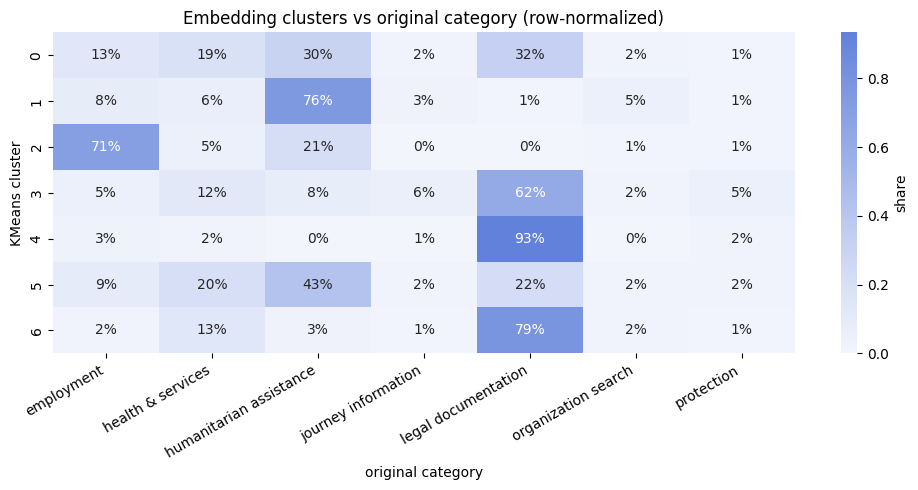

In [12]:
# Which original category dominates each embedding cluster? (row-normalized)
conf = pd.crosstab(user_docs.loc[known, "cluster_emb"],
                   user_docs.loc[known, "category"], normalize="index")
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(conf, annot=True, fmt=".0%", cmap=BLUE_CMAP, ax=ax, cbar_kws={"label": "share"})
ax.set_title("Embedding clusters vs original category (row-normalized)")
ax.set_xlabel("original category"); ax.set_ylabel("KMeans cluster")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()

## 4. Emergent themes — needs the taxonomy (and maybe the bot) misses

**What this shows, and why it matters.** For each embedding cluster: its size, the
dominant MMC category, that category's *purity*, and its most distinctive terms. A
**low-purity** cluster is not cleanly explained by any single official category —
its vocabulary points at a need the 7-category taxonomy does not name.

The aim is **not** to multiply analysis for its own sake (a fair critique of
open-ended theme-hunting). The actionable read is narrow: when a cluster surfaces a
recurring need the taxonomy has no slot for — the clearest example being
**transport / movement logistics** — that is precisely a class of questions the bot
is not built to answer. Each such gap is a concrete input to the **architecture
recommendation** (which new intents MMC should add), not an academic curiosity.

> **Technical note.** Purity = share of the dominant MMC category within the
> cluster; the 0.5 threshold is a heuristic, not a statistical test. Read the top
> terms to decide whether a low-purity cluster is a real coverage gap or just noise.

In [13]:
# Distinctive terms + dominant-category purity per embedding cluster.
terms = np.array(tfidf.get_feature_names_out())
rows = []
for c in range(K):
    m = (user_docs["cluster_emb"] == c).values
    centroid = np.asarray(X_tfidf[m].mean(axis=0)).ravel()
    top_terms = ", ".join(terms[centroid.argsort()[::-1][:8]])
    vc = user_docs.loc[m, "category"].value_counts()
    dom, pur = vc.index[0], vc.iloc[0] / vc.sum()
    rows.append({"cluster": c, "users": int(m.sum()), "dominant_category": dom,
                 "purity": round(float(pur), 2), "top_terms": top_terms})
themes = pd.DataFrame(rows).sort_values("purity").reset_index(drop=True)

PURITY_EMERGENT = 0.5   # below this, no single official category explains the cluster
themes["emergent"] = themes["purity"] < PURITY_EMERGENT
print(f"{int(themes['emergent'].sum())} candidate emergent cluster(s) "
      f"(purity < {PURITY_EMERGENT})")
themes

2 candidate emergent cluster(s) (purity < 0.5)


,cluster,users,dominant_category,purity,top_terms,emergent
0,0,140,legal documentation,0.32,"necesitar, salud, ayuda, querer, ayudar, yo, g...",True
1,5,55,humanitarian assistance,0.42,"humanitario, ayuda, gracias, medellín, empleo,...",True
2,3,103,legal documentation,0.60,"querer, visa, permiso, salvoconducto, requisit...",False
3,2,80,employment,0.71,"emprendimiento, empleo, ayuda, buscar, querer,...",False
4,1,111,humanitarian assistance,0.76,"ayuda, humanitario, querer, migrant, bogotá, r...",False
5,6,113,legal documentation,0.78,"ppt, sacar, querer, año, rumv, tutor, obtener,...",False
6,4,198,legal documentation,0.92,"colombia, colombiano, permiso, venezolano, ppt...",False


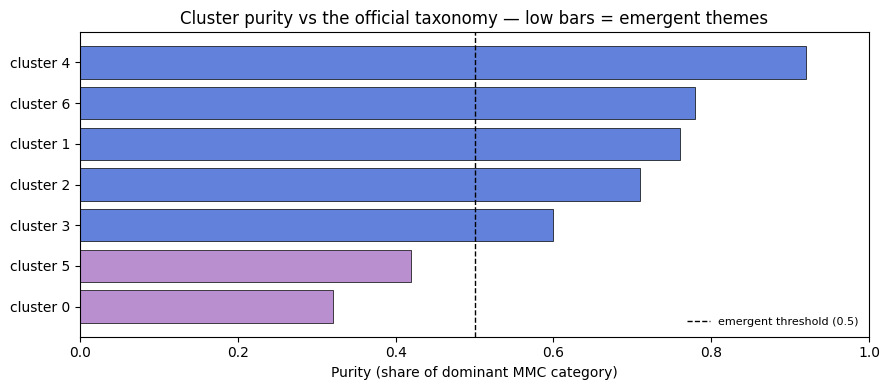

Candidate emergent themes (read the top terms):
  cluster 0 (n=140, purity 0.32): necesitar, salud, ayuda, querer, ayudar, yo, gracias, medellín
  cluster 5 (n=55, purity 0.42): humanitario, ayuda, gracias, medellín, empleo, informacion, refugio, asistencia


In [14]:
# Purity per cluster -- low bars (below the dashed line) are the emergent themes.
order = themes.sort_values("purity")
colors = [CAT_COLORS.get("emergent", NEGRO) if e else AGUA for e in order["emergent"]]
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh([f"cluster {c}" for c in order["cluster"]], order["purity"],
        color=colors, edgecolor=NEGRO, lw=.5)
ax.axvline(PURITY_EMERGENT, color=NEGRO, ls="--", lw=1, label=f"emergent threshold ({PURITY_EMERGENT})")
ax.set_xlim(0, 1)
ax.set_xlabel("Purity (share of dominant MMC category)")
ax.set_title("Cluster purity vs the official taxonomy — low bars = emergent themes")
ax.legend(fontsize=8, frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

print("Candidate emergent themes (read the top terms):")
for _, r in themes[themes["emergent"]].iterrows():
    print(f"  cluster {r['cluster']} (n={r['users']}, purity {r['purity']}): {r['top_terms']}")

## 5. Tinted embedding maps

*Project the 1024-d user embeddings to 2D/3D with **PCA** (visualization only —
KMeans used the full embeddings) and tint by original MMC category and by
KMeans cluster.*

In [15]:
# PCA to 3 components (deterministic, no extra dependency).
from sklearn.decomposition import PCA

pca = PCA(n_components=3, random_state=42)
proj = pca.fit_transform(emb)
user_docs[["px", "py", "pz"]] = proj
print("explained variance (3 comps):", pca.explained_variance_ratio_.round(3),
      "-> total", float(pca.explained_variance_ratio_[:3].sum().round(3)))

explained variance (3 comps): [0.068 0.052 0.038] -> total 0.15800000727176666


### 5.1 Tinted by original MMC category

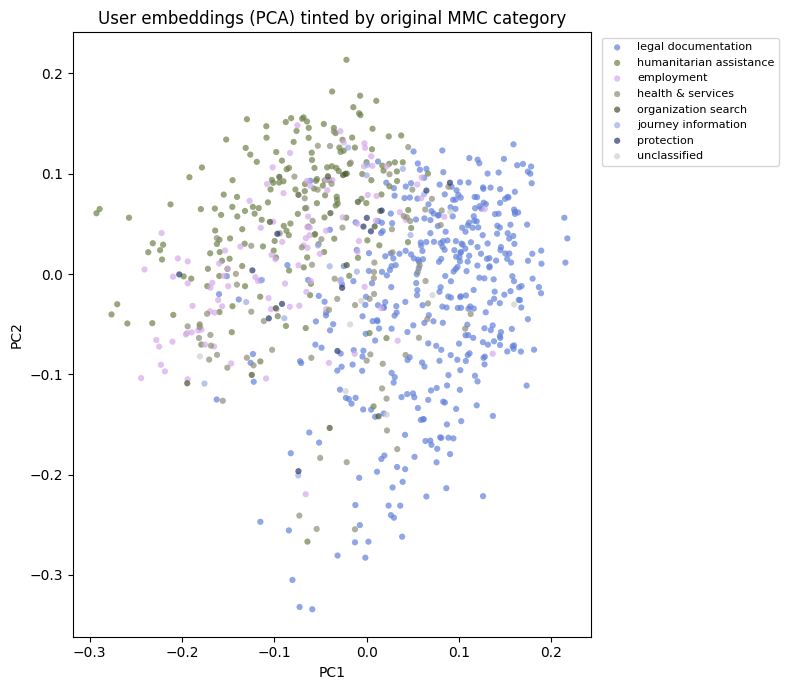

In [16]:
fig, ax = plt.subplots(figsize=(8, 7))
for cat in user_docs["category"].value_counts().index:
    m = user_docs["category"] == cat
    ax.scatter(user_docs.loc[m, "px"], user_docs.loc[m, "py"], s=20, alpha=.7,
               color=CAT_COLORS.get(cat, NEGRO), label=cat, edgecolor="none")
ax.set_title("User embeddings (PCA) tinted by original MMC category")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()

### 5.2 Tinted by KMeans cluster

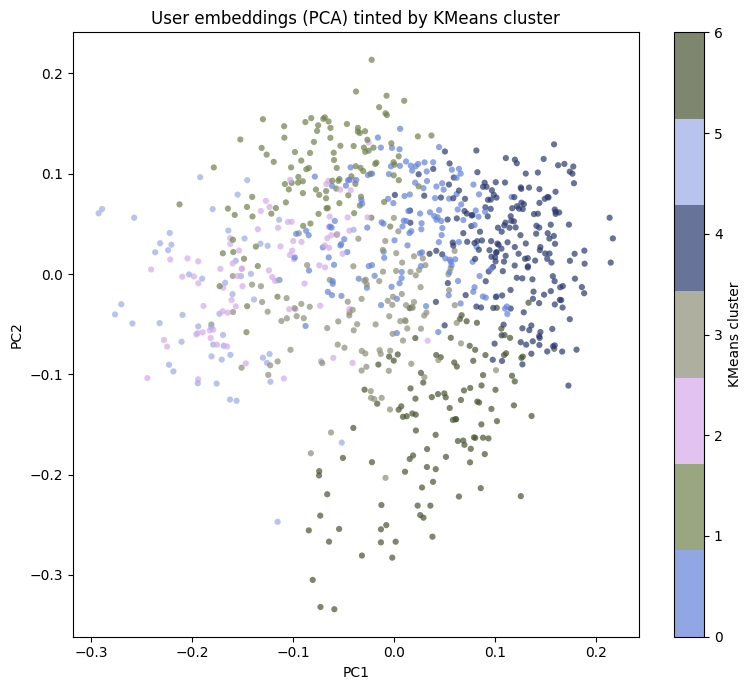

In [17]:
fig, ax = plt.subplots(figsize=(8, 7))
sc = ax.scatter(user_docs["px"], user_docs["py"], c=user_docs["cluster_emb"],
                cmap=CAT_CMAP, s=20, alpha=.7, edgecolor="none")
ax.set_title("User embeddings (PCA) tinted by KMeans cluster")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.colorbar(sc, ax=ax, label="KMeans cluster")
plt.tight_layout()

### 5.3 Interactive 3D (Plotly) tinted by category

In [18]:
# Interactive 3D scatter of the PCA projection, tinted by original category.
import plotly.express as px

fig = px.scatter_3d(
    user_docs, x="px", y="py", z="pz", color="category",
    color_discrete_map={k: v for k, v in CAT_COLORS.items()},
    hover_data={"cluster_emb": True, "px": False, "py": False, "pz": False},
    title="User embeddings (PCA 3D) tinted by original MMC category")
fig.update_traces(marker=dict(size=3, opacity=0.8))
fig.update_layout(legend_title_text="MMC category", height=700)
fig.show()

## 6. Qualitative voices

**What this shows.** The users in their own words — a word cloud of the MEAL
recommendations and a thematic read of the substantive free-text comments.

> **Technical note.** The comments are user testimony in Spanish; they are shown
> verbatim (translating them would falsify the data). Only the chart framing is
> in English.

In [19]:
# MEAL survey (phone-keyed) -- source of the free-text recommendations.
_meal = load_meal()
print(f"MEAL responses: {len(_meal)}  |  with a recommendation: {_meal['recommendation'].notna().sum()}")

MEAL responses: 78  |  with a recommendation: 77


### 6.1 Word cloud of recommendations

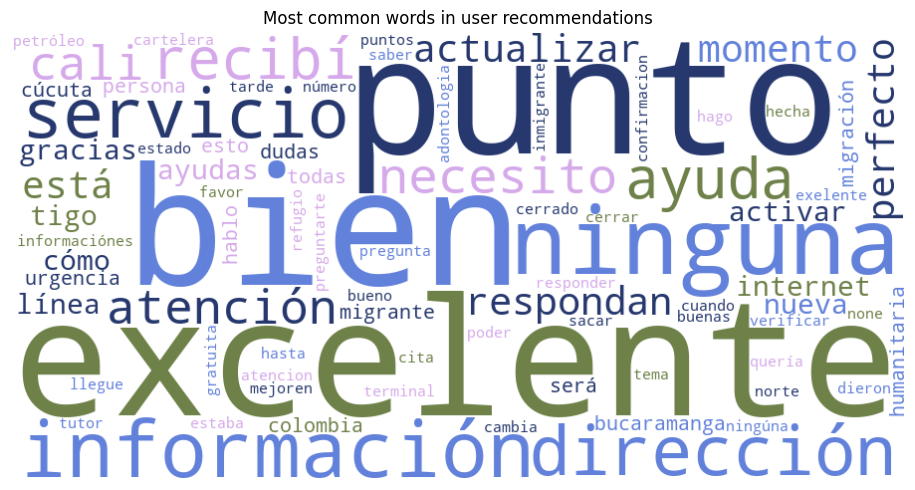

In [20]:
# Common Spanish stopwords to exclude so the cloud highlights meaningful themes.
ES_STOPWORDS = {
    'de', 'la', 'el', 'en', 'y', 'a', 'que', 'no', 'es', 'se', 'los', 'las',
    'con', 'por', 'un', 'una', 'para', 'más', 'del', 'al', 'lo', 'le', 'su',
    'me', 'mi', 'como', 'muy', 'pero', 'si', 'ya', 'este', 'esta', 'son', 'hay',
    'fue', 'ser', 'tiene', 'han', 'he', 'nos', 'sus', 'todo', 'también',
}
rec_text = _meal['recommendation'].dropna()
all_words = ' '.join(rec_text.str.lower()).split()
words = [w.strip('.,;:!?()\"\'') for w in all_words
         if len(w) > 3 and w.strip('.,;:!?()\"\'') not in ES_STOPWORDS]
word_freq = Counter(words)

# Colour words from the categorical palette so the cloud matches the notebook.
def _brand_color_func(word, font_size, position, orientation, random_state, **kwargs):
    pool = [AGUA, DARKBLUE, ARBOL, AMEBA]
    return pool[random_state.randint(0, len(pool) - 1)]

wc = WordCloud(width=900, height=450, background_color=SURFACE,
               color_func=_brand_color_func, prefer_horizontal=0.9
               ).generate_from_frequencies(word_freq)

fig, ax = plt.subplots(figsize=(10, 5))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Most common words in user recommendations', fontsize=12)
plt.tight_layout()
plt.show()

### 6.2 Free-text recommendations (thematic read)

*Substantive comments only (non-answers such as "no" / "ninguna" filtered out).*

In [21]:
recs = _meal["recommendation"].dropna().astype(str)
recs = recs[~recs.str.strip().str.lower().isin(["no", "ninguna", "ninguno", "nada"])]
print(f"{len(recs)} substantive recommendations\n")
for t in recs.head(20):
    print("•", t)

42 substantive recommendations

• Excelente
• Ayuda, no se cómo activar mi línea nueva Tigo y mi internet
• No recibí ninguna información.
• No recibí información
• Todo bien gracias 😌🫂
• Ayudas en Bucaramanga
• Me necesito hablo con persona ! Esto es urgencia !!!!
• Será que hay un punto de atención para los migrante vía cali
• Que respondan todas las dudas
• Actualizar la dirección de Migración Colombia en Cúcuta
• Ayuda humanitaria
• Q dan informaciónes buenas
• Llegue al punto a la una de la tarde y estaba cerrado el punto de atencion en la terminal del norte. Favor no cerrar los puntos
• Poder responder a la pregunta hecha cuando cambia el tema
• necesito saber la dirección de un refugio en cali
• Si , actualizar la información
• Todo esta perfecto
• Perfecto
• El servicio es muy excelente
• No por el momento


## 7. Sentiment — an unsolicited distress signal

*3-class sentiment on every message; the tone users did not have to state
explicitly (**H3**).*

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

sentiment: {'negative': np.int64(480), 'neutral': np.int64(2302), 'positive': np.int64(211)} |  negative share: 16.0%


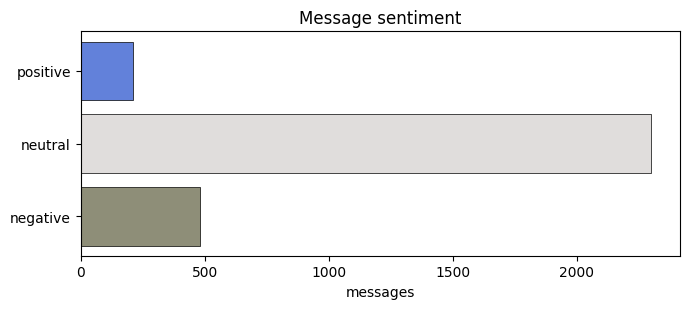

In [22]:
# 3-class sentiment per message.
from transformers import pipeline

texts = msgs["message"].astype(str).tolist()
sent_clf = pipeline("sentiment-analysis",
                    model="cardiffnlp/twitter-xlm-roberta-base-sentiment",
                    device=GPU, truncation=True, max_length=256)

def _norm_sent(label):
    l = label.lower()
    if "neg" in l or l.endswith("0"):
        return "negative"
    if "pos" in l or l.endswith("2"):
        return "positive"
    return "neutral"

preds = sent_clf([t[:256] for t in texts], batch_size=32)
msgs["sentiment"] = [_norm_sent(p["label"]) for p in preds]
del sent_clf
if DEVICE == "cuda":
    torch.cuda.empty_cache()

SENT_ORDER = ["negative", "neutral", "positive"]
SENT_COLORS = {"negative": MADERA, "neutral": HONGO, "positive": AGUA}
fig, ax = plt.subplots(figsize=(7, 3.2))
sd = msgs["sentiment"].value_counts().reindex(SENT_ORDER)
ax.barh(SENT_ORDER, sd.values, color=[SENT_COLORS[s] for s in SENT_ORDER],
        edgecolor=NEGRO, lw=.5)
ax.set_title("Message sentiment"); ax.set_xlabel("messages")
plt.tight_layout()
print("sentiment:", dict(sd), f"|  negative share: {sd['negative']/sd.sum()*100:.1f}%")

### 7.1 Sentiment by category

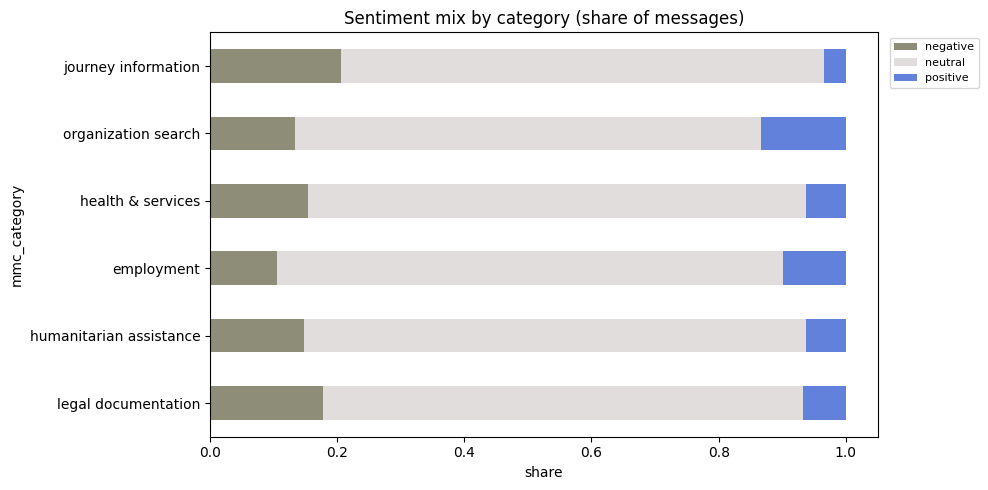

In [23]:
cats6 = (msgs[~msgs["mmc_category"].isin(NON_TOPIC_CATS)]["mmc_category"]
         .value_counts().head(6).index)
sub = msgs[msgs["mmc_category"].isin(cats6)]
tabS = (pd.crosstab(sub["mmc_category"], sub["sentiment"], normalize="index")
        .reindex(index=cats6, columns=SENT_ORDER, fill_value=0))
tabS.plot(kind="barh", stacked=True, figsize=(10, 5),
          color=[SENT_COLORS[s] for s in SENT_ORDER])
plt.title("Sentiment mix by category (share of messages)")
plt.xlabel("share"); plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()

## 8. Geographic synthesis — need + tone by city

**The closer of the whole analysis (**H4**).** Per city: dominant need (MMC
category) and mean tone of its messages.

> One bubble per city (size = messages), ≥ 15 mapped messages; sentiment is mean
> polarity (−1 / 0 / +1); category is the most common per city.

In [24]:
# City coordinates + per-city aggregates. The map itself uses a contextily
# basemap (no floating shapefile) -- see _basemap() below.
import unicodedata
import contextily as cx

CITY_COORDS = {
    "bogota": (-74.0721, 4.7110),   "medellin": (-75.5812, 6.2442),
    "cali": (-76.5320, 3.4516),     "barranquilla": (-74.7813, 10.9685),
    "cartagena": (-75.4794, 10.3910),"cucuta": (-72.5078, 7.8939),
    "bucaramanga": (-73.1227, 7.1193),"maicao": (-72.2382, 11.3776),
    "riohacha": (-72.9072, 11.5449),"ipiales": (-77.6417, 0.8256),
    "santa marta": (-74.1990, 11.2408),"soacha": (-74.2168, 4.5794),
    "necocli": (-76.7889, 8.4245),
}
def _strip(s):
    s = str(s).strip().lower()
    return "".join(c for c in unicodedata.normalize("NFKD", s) if not unicodedata.combining(c))

msgs["city_key"] = msgs["city_canon"].map(_strip)
matched = msgs["city_key"].isin(CITY_COORDS)
print(f"{msgs.loc[matched,'city_key'].nunique()} cities mapped, "
      f"covering {matched.mean()*100:.0f}% of messages")

MIN_MSGS = 15
SENT_SIGN = {"negative": -1, "neutral": 0, "positive": 1}
gm = msgs[matched & ~msgs["mmc_category"].isin(NON_TOPIC_CATS)].copy()
gm["sent_sign"] = gm["sentiment"].map(SENT_SIGN)
geo = gm.groupby("city_key").agg(msgs_n=("city_key", "size"), sentiment=("sent_sign", "mean"))
geo = geo[geo["msgs_n"] >= MIN_MSGS]
geo["dominant"] = gm.groupby("city_key")["mmc_category"].agg(lambda s: s.value_counts().index[0])
geo["lon"] = [CITY_COORDS[c][0] for c in geo.index]
geo["lat"] = [CITY_COORDS[c][1] for c in geo.index]
geo["label"] = [c.title() for c in geo.index]
geo = geo.sort_values("msgs_n", ascending=False)

def _basemap(ax, title):
    "Frame Colombia and drop a light CartoDB Positron basemap behind the bubbles."
    ax.set_xlim(-80, -66); ax.set_ylim(-4.5, 13)
    ax.set_aspect("equal")
    cx.add_basemap(ax, crs="EPSG:4326", zorder=0,
                   source=cx.providers.CartoDB.PositronNoLabels, attribution_size=6)
    ax.set_title(title); ax.set_axis_off()
def _sizes(frame):
    return 60 + (frame["msgs_n"] / frame["msgs_n"].max()) * 900
print(f"{len(geo)} cities with >= {MIN_MSGS} messages mapped")
display(geo[["label", "msgs_n", "sentiment", "dominant"]].reset_index(drop=True))

13 cities mapped, covering 88% of messages
11 cities with >= 15 messages mapped


,label,msgs_n,sentiment,dominant
0,Medellin,1086,-0.076427,legal documentation
1,Bogota,483,-0.086957,legal documentation
2,Barranquilla,303,-0.033003,legal documentation
3,Cucuta,193,-0.139896,legal documentation
4,Ipiales,153,-0.052288,humanitarian assistance
5,Santa Marta,141,-0.156028,legal documentation
6,Soacha,130,-0.092308,legal documentation
7,Maicao,41,-0.170732,legal documentation
8,Cali,30,-0.166667,organization search
9,Bucaramanga,22,0.045455,humanitarian assistance


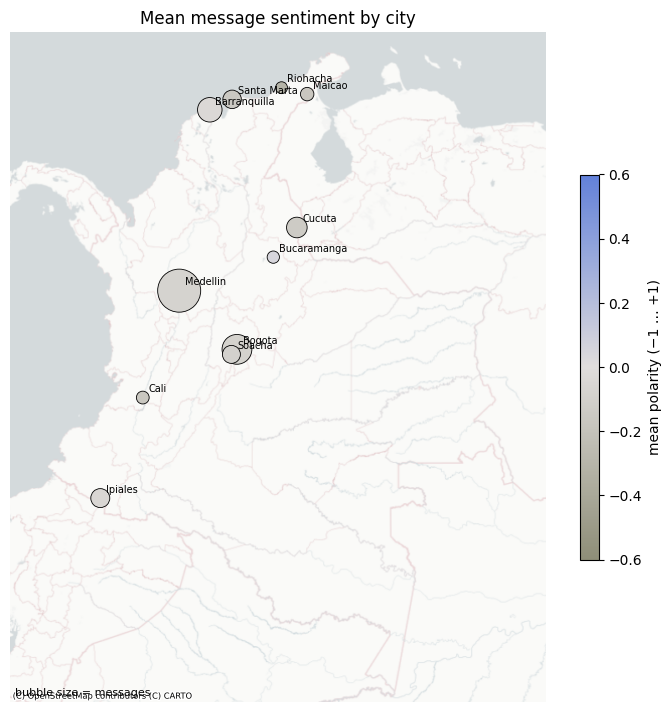

In [25]:
from matplotlib.colors import LinearSegmentedColormap
sent_cmap = LinearSegmentedColormap.from_list("mmc_sent", [MADERA, HONGO, AGUA])
fig, ax = plt.subplots(figsize=(7, 8))
_basemap(ax, "Mean message sentiment by city")
sc = ax.scatter(geo["lon"], geo["lat"], s=_sizes(geo), c=geo["sentiment"],
                cmap=sent_cmap, vmin=-0.6, vmax=0.6, edgecolor=NEGRO, lw=.6, zorder=2)
for _, r in geo.iterrows():
    ax.annotate(r["label"], (r["lon"], r["lat"]), fontsize=7, xytext=(4, 4),
                textcoords="offset points")
cbar = plt.colorbar(sc, ax=ax, shrink=0.5); cbar.set_label("mean polarity (−1 … +1)")
ax.text(0.01, 0.01, "bubble size = messages", transform=ax.transAxes, fontsize=8)
plt.tight_layout()

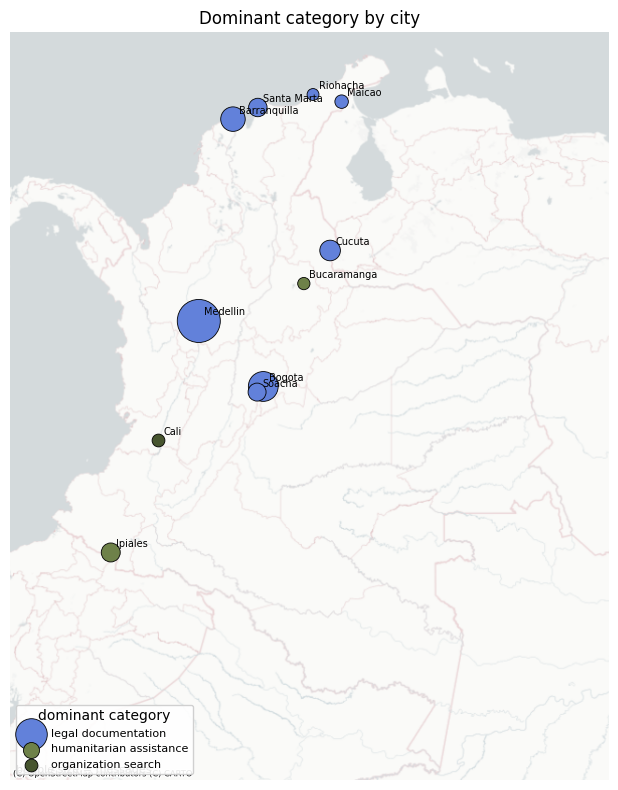

In [26]:
fig, ax = plt.subplots(figsize=(7, 8))
_basemap(ax, "Dominant category by city")
sizes = _sizes(geo)
for cat in geo["dominant"].unique():
    m = geo["dominant"] == cat
    ax.scatter(geo.loc[m, "lon"], geo.loc[m, "lat"], s=sizes[m],
               color=CAT_COLORS.get(cat, NEGRO), edgecolor=NEGRO, lw=.6, label=cat, zorder=2)
for _, r in geo.iterrows():
    ax.annotate(r["label"], (r["lon"], r["lat"]), fontsize=7, xytext=(4, 4),
                textcoords="offset points")
ax.legend(loc="lower left", fontsize=8, framealpha=.9, title="dominant category")
ax.text(0.01, 0.01, "bubble size = messages", transform=ax.transAxes, fontsize=8)
plt.tight_layout()

## 9. Cross-variable word clouds — needs by city, cluster, time & coverage

**What this shows.** The qualitative counterpart to the numeric cross-cuts of NB2:
instead of *counting* categories, we let the users' **own words** surface, sliced by
the variables that matter for design — **city, cluster / archetype, time, and
coverage**. Message text stays in **Spanish** (it is the raw testimony, as in §6.2);
only the framing is English. Greetings, filler and place names are stripped so each
cloud shows what is *distinctive* to its slice, not "cómo / colombia" everywhere.

Together these cover the cross-variable asks: topic modelling by theme / zone / period
(§9.1–§9.3), most-requested needs by city (§9.1), temporal shifts and spikes (§9.3),
geography (§9.1), repeated / unresolved questions (§9.4a) and content gaps (§9.4b).

In [27]:
# ---- shared helper for the cross-variable word clouds ------------------------
# Message text stays Spanish (the users' own words, as in §6.2); only titles are
# English. WC_STOP strips greetings, filler and PLACE NAMES (the facet already
# encodes place) so each cloud shows what is *distinctive* to its slice.
from collections import Counter
from wordcloud import WordCloud
import math

def _brand_color_func(word, font_size, position, orientation, random_state, **kwargs):
    pool = [AGUA, DARKBLUE, ARBOL, AMEBA]
    return pool[random_state.randint(0, len(pool) - 1)]   # stdlib randint is inclusive

WC_STOP = set(ES_STOPWORDS) | {
    # question words / generic verbs / filler
    "cómo", "como", "qué", "que", "cuál", "cual", "cuáles", "dónde", "donde", "cuándo",
    "cuando", "quién", "quien", "hola", "buenas", "buenos", "días", "dias", "tardes",
    "gracias", "favor", "porfavor", "quiero", "necesito", "saber", "información",
    "informacion", "ayuda", "ayudar", "puedo", "puede", "pueden", "podría", "poder",
    "debo", "hago", "hacer", "tener", "tengo", "estoy", "estar", "está", "están", "soy",
    "quisiera", "gustaría", "gustaria", "sami", "bot", "sobre", "aquí", "aqui", "algún",
    "alguna", "alguno", "alguien", "tipo", "otra", "otro", "cosa", "años", "año", "nada",
    "solo", "muchas", "mucho", "poco", "bien", "aún", "aun", "este", "esta", "esto",
    "para", "por", "con", "los", "las", "una", "uno", "pero", "más", "muy", "son", "fue",
    "han", "hay", "sin", "sus", "nos", "les", "tan", "ya",
    # geography (the facet already encodes place; country / city names are noise here)
    "colombia", "venezuela", "medellin", "medellín", "bogota", "bogotá", "cucuta",
    "cúcuta", "barranquilla", "ipiales", "santa", "marta", "cali", "cartagena",
    "bucaramanga", "soacha", "riohacha", "maicao", "necoclí", "necocli", "pasto",
    "cundinamarca", "antioquia", "país", "pais"}

def _wc_freq(texts):
    "Cleaned Spanish token frequencies from an iterable of message strings."
    words = []
    for t in texts:
        if not isinstance(t, str):
            continue
        for w in t.lower().split():
            w = "".join(ch for ch in w if ch.isalpha())
            if len(w) > 3 and w not in WC_STOP:
                words.append(w)
    return Counter(words)

def brand_wordcloud_grid(groups, title, subtitle="", ncols=3, min_words=8):
    "groups: {label: iterable of message strings} -> one brand-coloured cloud each."
    items = [(lab, _wc_freq(txts)) for lab, txts in groups.items()]
    items = [(lab, f) for lab, f in items if len(f) >= min_words]
    if not items:
        print("(not enough text to build a cloud)")
        return
    nrows = math.ceil(len(items) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 3.3 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, (lab, freq) in zip(axes, items):
        wc = WordCloud(width=520, height=360, background_color=SURFACE,
                       color_func=_brand_color_func, prefer_horizontal=0.9,
                       max_words=40).generate_from_frequencies(freq)
        ax.imshow(wc, interpolation="bilinear"); ax.axis("off")
        ax.set_title(lab, fontsize=11, color=INK)
    for ax in axes[len(items):]:
        ax.axis("off")
    fig.suptitle(title + ("\n" + subtitle if subtitle else ""), fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

### 9.1 By city — what each place asks about

Geography + needs in one view: the vocabulary of each of the top-6 cities. Watch how
**border / transit towns** (e.g. Ipiales — *refugio, albergue, terminal*) read
differently from **settling cities** (Medellín, Bogotá — *permiso, salud, trabajo*).

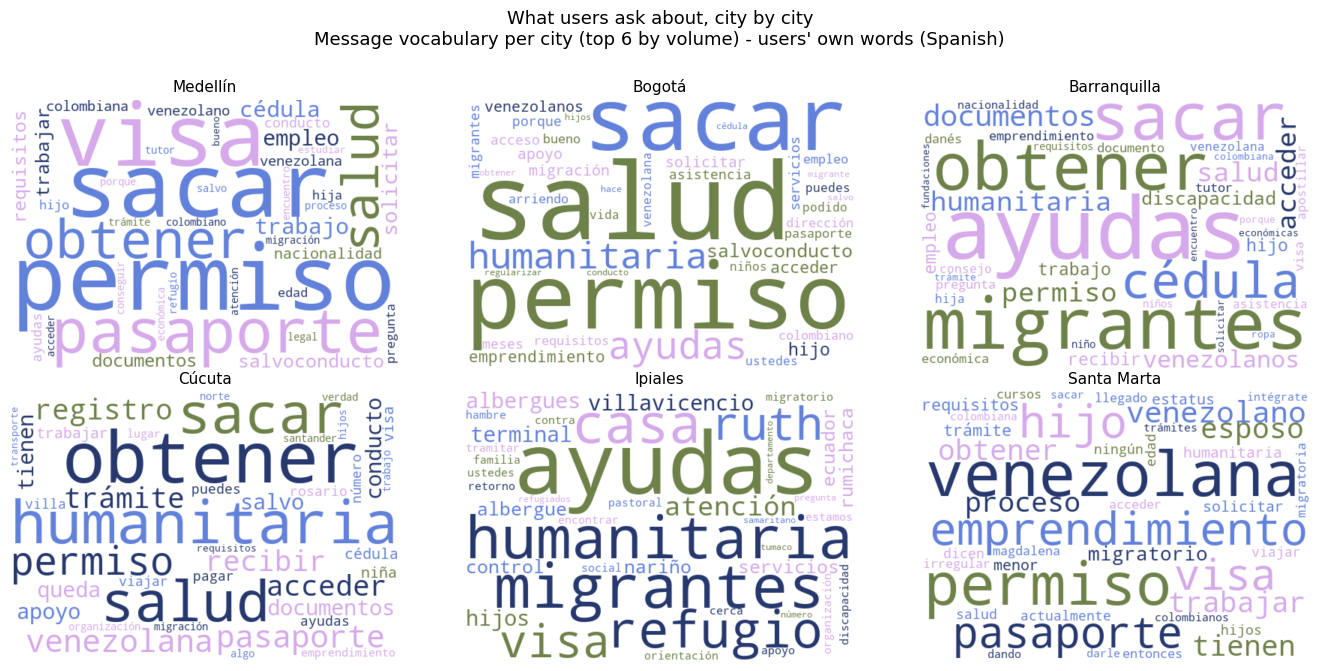

In [28]:
# §9.1 -- message vocabulary by CITY (top 6 by volume). Border / transit towns
# (Ipiales) read differently from settling cities (Medellín, Bogotá).
top_cities = (msgs.loc[msgs["city_canon"] != "Otra", "city_canon"]
              .value_counts().head(6).index.tolist())
brand_wordcloud_grid(
    {c: msgs.loc[msgs["city_canon"] == c, "message"] for c in top_cities},
    "What users ask about, city by city",
    "Message vocabulary per city (top 6 by volume) - users' own words (Spanish)")

### 9.3 Over time — month-by-month shifts and spikes

The temporal view: one cloud per month. A term that balloons in one month and fades
the next is a demand *spike* worth correlating with events (see the H3 note in NB2 §5.2).

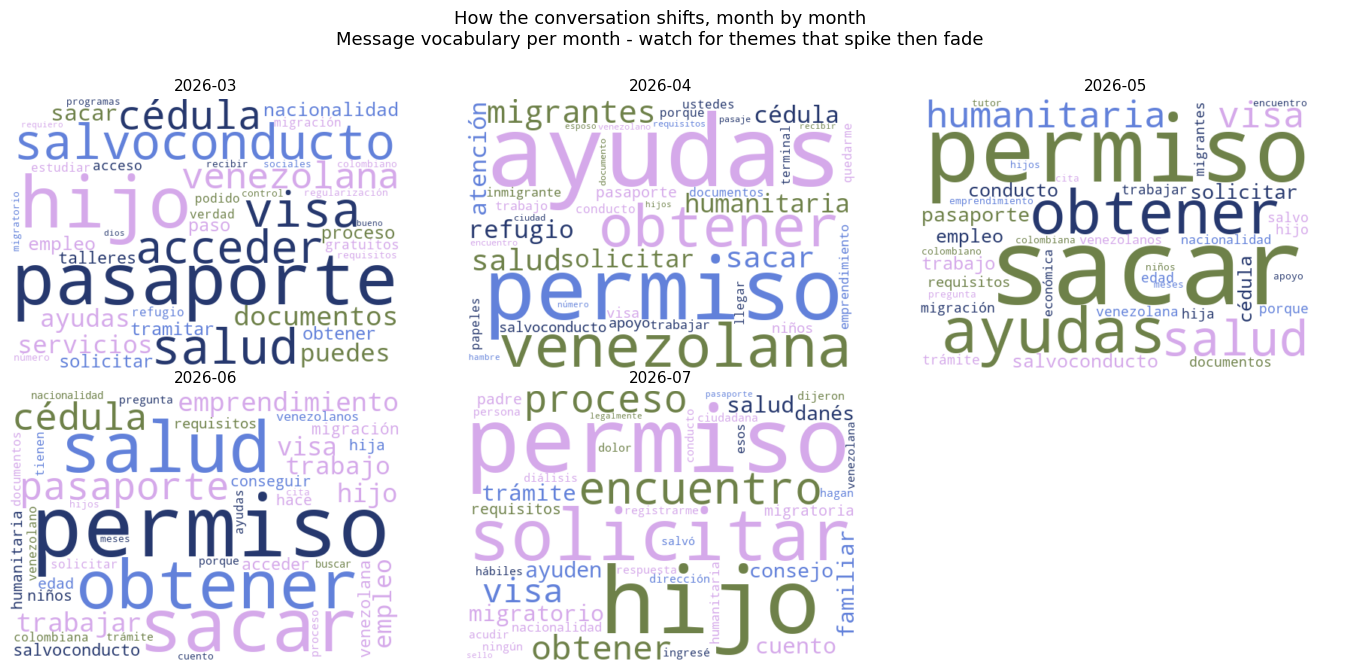

In [30]:
# §9.3 -- message vocabulary by MONTH (temporal shifts / spikes in what is asked).
_mp = msgs.dropna(subset=["ts"]).copy()
_mp["period"] = _mp["ts"].dt.to_period("M").astype(str)
periods = sorted(_mp["period"].unique())
brand_wordcloud_grid(
    {p: _mp.loc[_mp["period"] == p, "message"] for p in periods},
    "How the conversation shifts, month by month",
    "Message vocabulary per month - watch for themes that spike then fade")

### 9.4 Repeat-askers & content gaps — inputs to the bot's architecture

Two design-facing reads: **(a)** the users who **keep asking** (high message volume or
a repeated question) — a proxy for needs the bot did not resolve in one turn; and
**(b)** the **content gaps** — the vocabulary of the low-coverage emergent clusters
(§4), i.e. themes the taxonomy names poorly and candidate **new bot intents**.

102 users flagged as repeat / high-volume askers (13% of users)


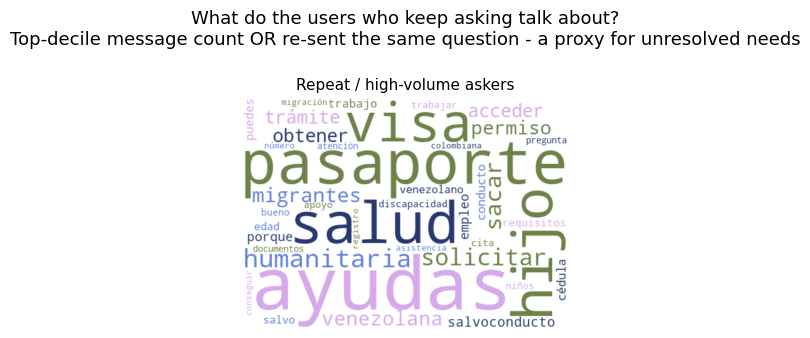

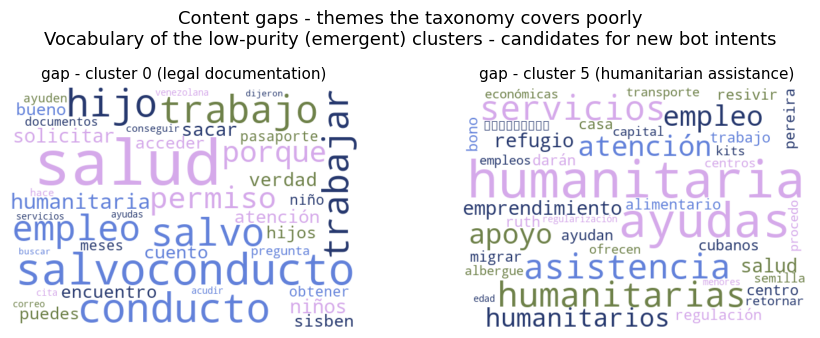

In [31]:
# §9.4a -- REPEAT-ASKERS: users who send many messages OR re-send a near-identical
# question are a proxy for needs the bot did not resolve in one turn.
def _norm_q(t):
    t = _fold(t)
    return "".join(ch for ch in t if ch.isalpha() or ch == " ").strip()

_pu = msgs.groupby("phone")
_counts = _pu["message"].size()
_repeats = _pu["message"].apply(lambda s: s.map(_norm_q).duplicated().any())
_heavy = _counts >= _counts.quantile(0.90)
repeat_phones = _counts.index[_heavy | _repeats]
print(f"{len(repeat_phones)} users flagged as repeat / high-volume askers "
      f"({len(repeat_phones) / msgs['phone'].nunique() * 100:.0f}% of users)")
brand_wordcloud_grid(
    {"Repeat / high-volume askers": msgs.loc[msgs["phone"].isin(repeat_phones), "message"]},
    "What do the users who keep asking talk about?",
    "Top-decile message count OR re-sent the same question - a proxy for unresolved needs",
    ncols=1)

# §9.4b -- CONTENT GAPS: the vocabulary of the low-purity (emergent) clusters -- needs
# the 7-category taxonomy (and the bot) covers poorly, and candidate new intents.
gap_clusters = themes.loc[themes["emergent"], "cluster"].tolist()
if gap_clusters:
    brand_wordcloud_grid(
        {f"gap - cluster {int(c)} ({_dom.get(int(c), '?')})":
         msgs.loc[msgs["cluster_emb"] == c, "message"] for c in gap_clusters},
        "Content gaps - themes the taxonomy covers poorly",
        "Vocabulary of the low-purity (emergent) clusters - candidates for new bot intents",
        ncols=min(3, len(gap_clusters)))
else:
    print("No emergent (low-purity) clusters at the current threshold -- no gap clouds.")